# 🏠 California Housing — Full ML Pipeline
### Group Project | Supervised & Unsupervised Learning

---

| Section | Topic |
|---------|-------|
| 📂 | Dataset Loading & EDA |
| 🔧 | Feature Engineering & Preprocessing |
| 🤖 | Model Training (3+ models) |
| 📊 | Evaluation — Metrics, Confusion Matrix, ROC |
| ⚙️ | Hyperparameter Tuning |
| 🧩 | Unsupervised Learning (Clustering) |
| 🏆 | Final Results & Findings |


## 📦 Install & Import Libraries

In [1]:
# Install any extra libraries if needed
!pip install -q xgboost shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — Data
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Sklearn — Supervised Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Sklearn — Unsupervised
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Sklearn — Evaluation (Regression)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

# Classification (for binary task)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

import shap

# Style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
print('✅ All libraries loaded!')

✅ All libraries loaded!


---
## 📂 Section 1 — Dataset Loading & EDA

In [2]:
# ── Load Dataset ──────────────────────────────────────────────
raw = fetch_california_housing(as_frame=True)
df  = raw.frame.copy()

print('Dataset shape:', df.shape)
print('\nFeature descriptions:')
for name, desc in zip(raw.feature_names, raw.DESCR.split('\n')[12:20]):
    print(f'  {name:15s} →', desc.strip())
df.head()

Dataset shape: (20640, 9)

Feature descriptions:
  MedInc          → - MedInc        median income in block group
  HouseAge        → - HouseAge      median house age in block group
  AveRooms        → - AveRooms      average number of rooms per household
  AveBedrms       → - AveBedrms     average number of bedrooms per household
  Population      → - Population    block group population
  AveOccup        → - AveOccup      average number of household members
  Latitude        → - Latitude      block group latitude
  Longitude       → - Longitude     block group longitude


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# ── Basic Info ────────────────────────────────────────────────
print('=== Data Types & Missing Values ===')
info_df = pd.DataFrame({
    'Dtype'  : df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Missing' : df.isnull().sum(),
    'Missing%': (df.isnull().mean()*100).round(2)
})
display(info_df)
print('\n=== Descriptive Statistics ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== Data Types & Missing Values ===


,Dtype,Non-Null,Missing,Missing%
MedInc,float64,20640,0,0.0
HouseAge,float64,20640,0,0.0
AveRooms,float64,20640,0,0.0
AveBedrms,float64,20640,0,0.0
Population,float64,20640,0,0.0
AveOccup,float64,20640,0,0.0
Latitude,float64,20640,0,0.0
Longitude,float64,20640,0,0.0
MedHouseVal,float64,20640,0,0.0



=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.000000,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.000000,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.000000,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.000000,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.000000,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.000000,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.000000,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.000000,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.000000,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


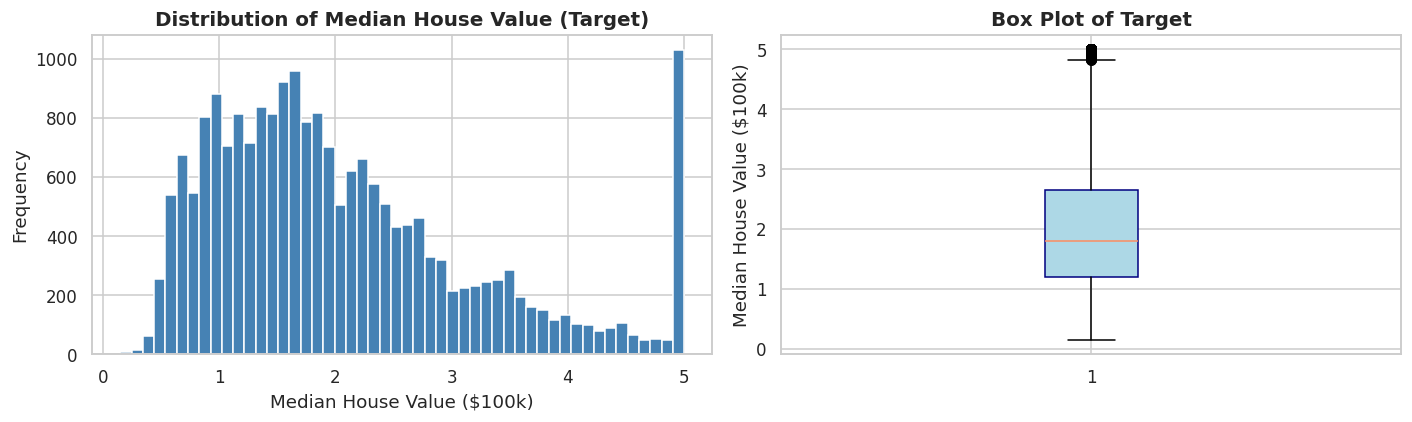


Skewness: 0.978
Kurtosis: 0.328


In [4]:
# ── Target Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value (Target)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'))
axes[1].set_title('Box Plot of Target', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Median House Value ($100k)')

plt.tight_layout()
plt.show()

print(f'\nSkewness: {df["MedHouseVal"].skew():.3f}')
print(f'Kurtosis: {df["MedHouseVal"].kurt():.3f}')

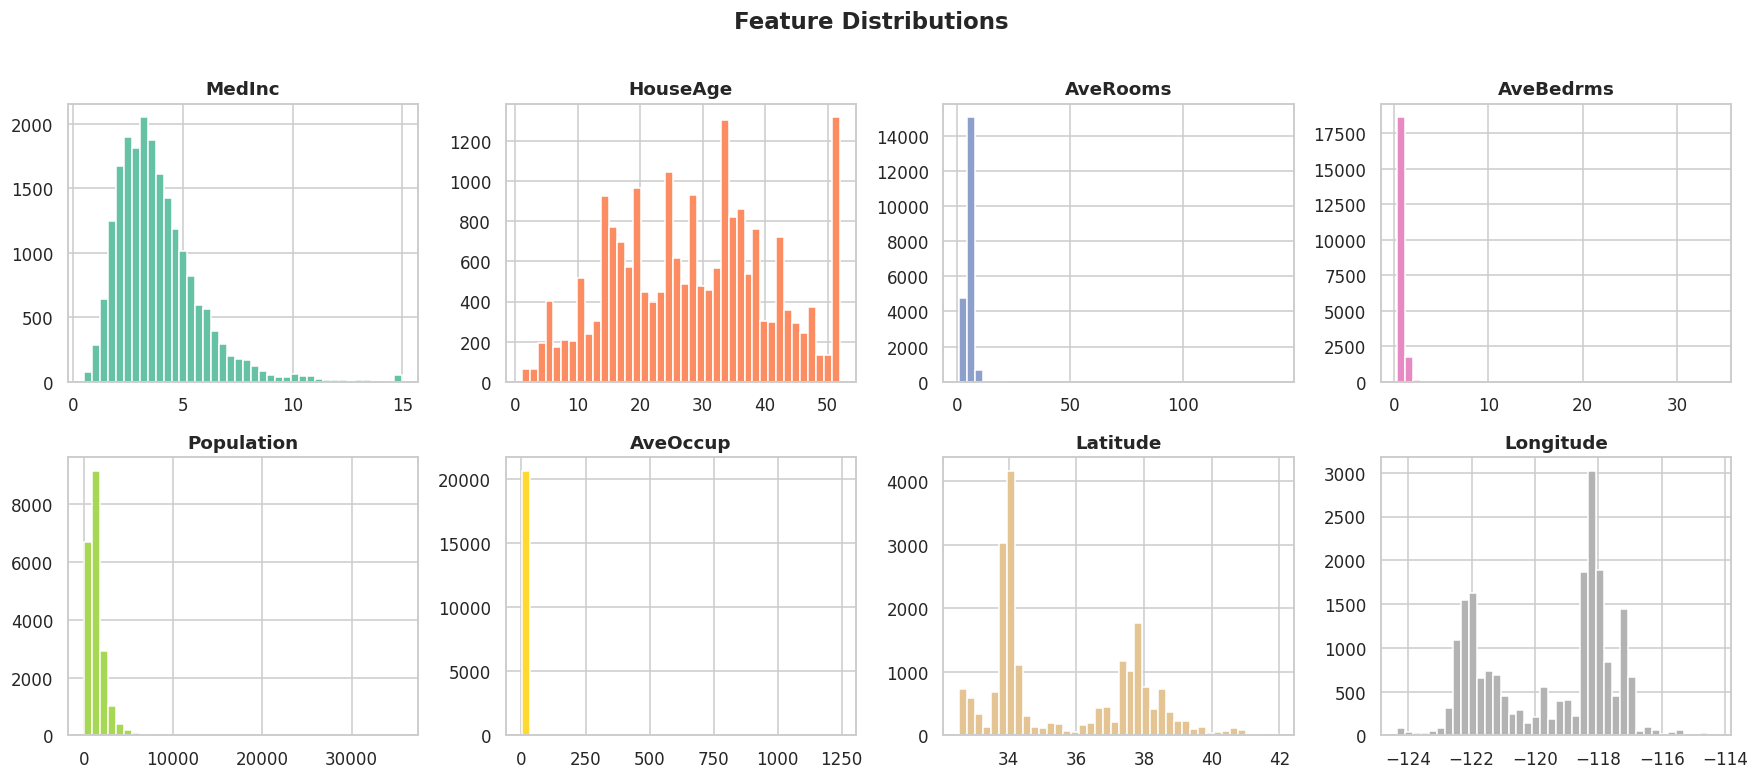

In [5]:
# ── Feature Distributions ─────────────────────────────────────
features = raw.feature_names
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color=sns.color_palette('Set2')[i % 8], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

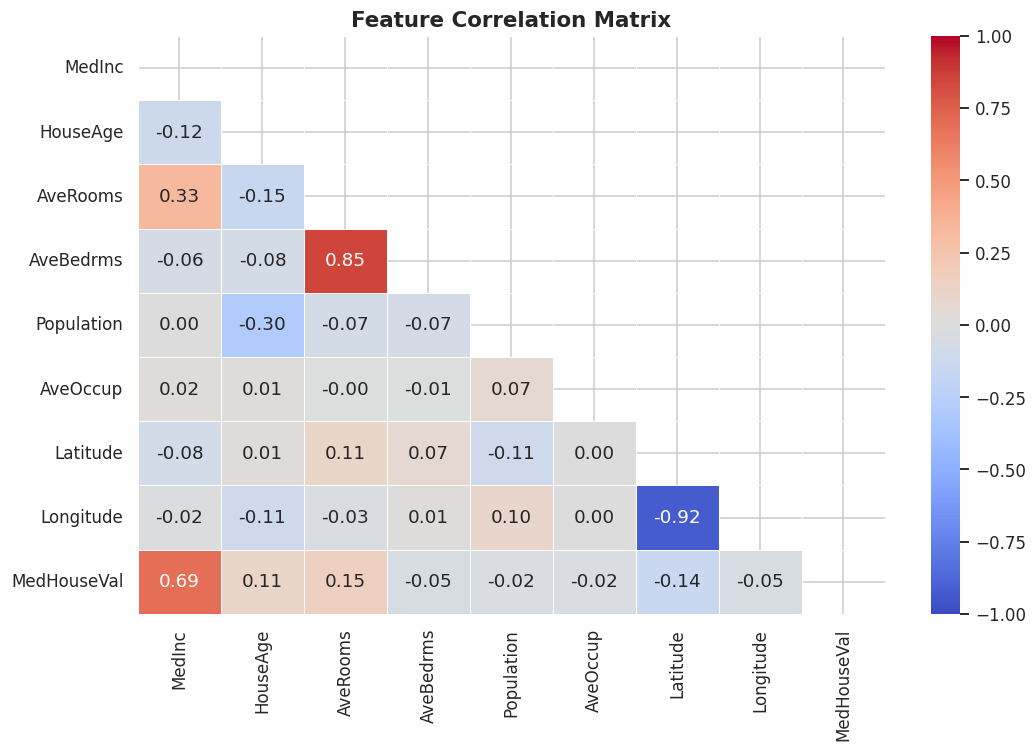


🔑 Top correlations with MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160


In [6]:
# ── Correlation Heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔑 Top correlations with MedHouseVal:')
print(corr['MedHouseVal'].sort_values(ascending=False).to_string())

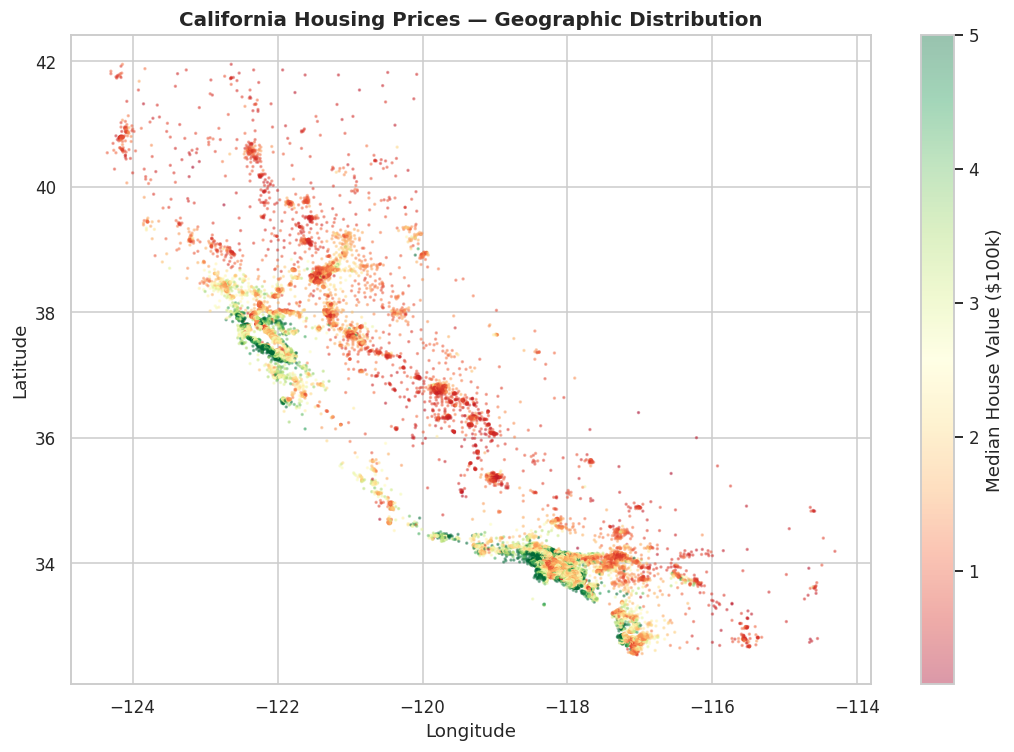

In [7]:
# ── Geographic Scatter ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(df['Longitude'], df['Latitude'],
                c=df['MedHouseVal'], cmap='RdYlGn',
                alpha=0.4, s=1.5)
plt.colorbar(sc, ax=ax, label='Median House Value ($100k)')
ax.set_title('California Housing Prices — Geographic Distribution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---
## 🔧 Section 2 — Feature Engineering & Preprocessing

In [8]:
# ── Feature Engineering ───────────────────────────────────────
df_eng = df.copy()

# Rooms per person & household ratios
df_eng['RoomsPerHousehold']    = df_eng['AveRooms']   / df_eng['HouseAge'].clip(lower=1)
df_eng['BedroomsPerRoom']      = df_eng['AveBedrms']  / df_eng['AveRooms'].clip(lower=1)
df_eng['PopulationPerHousehold'] = df_eng['Population'] / df_eng['AveOccup'].clip(lower=1)
df_eng['IncomePerRoom']        = df_eng['MedInc']     / df_eng['AveRooms'].clip(lower=1)

# Log transform skewed features
for col in ['Population', 'AveOccup']:
    df_eng[f'Log_{col}'] = np.log1p(df_eng[col])

# Distance to major CA cities (rough centroids)
la_lat, la_lon = 34.05, -118.24
sf_lat, sf_lon = 37.77, -122.42
df_eng['DistToLA'] = np.sqrt((df_eng['Latitude']-la_lat)**2 + (df_eng['Longitude']-la_lon)**2)
df_eng['DistToSF'] = np.sqrt((df_eng['Latitude']-sf_lat)**2 + (df_eng['Longitude']-sf_lon)**2)

new_features = ['RoomsPerHousehold','BedroomsPerRoom','PopulationPerHousehold',
                'IncomePerRoom','Log_Population','Log_AveOccup','DistToLA','DistToSF']
print(f'✅ Added {len(new_features)} engineered features:')
print(new_features)
df_eng[new_features].describe().T.round(3)

✅ Added 8 engineered features:
['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold', 'IncomePerRoom', 'Log_Population', 'Log_AveOccup', 'DistToLA', 'DistToSF']


,count,mean,std,min,25%,50%,75%,max
RoomsPerHousehold,20640.0,0.282,0.390,0.018,0.128,0.180,0.302,20.125
BedroomsPerRoom,20640.0,0.213,0.058,0.100,0.175,0.203,0.240,1.000
PopulationPerHousehold,20640.0,499.539,382.331,1.000,280.000,409.000,605.000,6082.000
IncomePerRoom,20640.0,0.715,0.255,0.013,0.543,0.708,0.862,4.594
Log_Population,20640.0,7.026,0.736,1.386,6.669,7.062,7.454,10.482
Log_AveOccup,20640.0,1.352,0.208,0.526,1.232,1.340,1.454,7.126
DistToLA,20640.0,2.646,2.418,0.000,0.318,1.691,5.207,9.870
DistToSF,20640.0,3.878,2.497,0.000,1.210,5.265,5.842,9.308


In [9]:
# ── Outlier Treatment ─────────────────────────────────────────
def cap_outliers_iqr(df, cols, factor=3.0):
    df = df.copy()
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor*IQR, Q3 + factor*IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower, upper)
        if n_out: print(f'  {col}: capped {n_out} outliers')
    return df

cap_cols = ['AveRooms','AveBedrms','AveOccup','Population']
print('Outlier capping (IQR × 3):')
df_eng = cap_outliers_iqr(df_eng, cap_cols)
print('Done ✅')

Outlier capping (IQR × 3):
  AveRooms: capped 180 outliers
  AveBedrms: capped 724 outliers
  AveOccup: capped 132 outliers
  Population: capped 421 outliers
Done ✅


In [10]:
# ── Train / Test Split ────────────────────────────────────────
TARGET = 'MedHouseVal'
X = df_eng.drop(columns=[TARGET])
y = df_eng[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set: {X_train.shape}  |  Test set: {X_test.shape}')

# Scaling
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print('✅ Features scaled with StandardScaler')

Train set: (16512, 16)  |  Test set: (4128, 16)
✅ Features scaled with StandardScaler


---
## 🤖 Section 3 — Model Training (Supervised — Regression)

In [11]:
# ── Define Models ─────────────────────────────────────────────
models = {
    'Linear Regression'        : LinearRegression(),
    'Ridge Regression'         : Ridge(alpha=1.0),
    'Lasso Regression'         : Lasso(alpha=0.01),
    'Decision Tree'            : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'            : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                  : XGBRegressor(n_estimators=100, random_state=42,
                                              verbosity=0, n_jobs=-1),
    'SVR'                      : SVR(kernel='rbf', C=5, epsilon=0.1)
}

def evaluate_regression(model, X_tr, X_te, y_tr, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    r2    = r2_score(y_te, preds)
    mape  = mean_absolute_percentage_error(y_te, preds) * 100
    return dict(RMSE=round(rmse,4), MAE=round(mae,4), R2=round(r2,4), MAPE=round(mape,2))

results = {}
print('Training models...\n')
for name, model in models.items():
    use_scaled = name in ['Linear Regression','Ridge Regression','Lasso Regression','SVR']
    Xtr = X_train_s if use_scaled else X_train.values
    Xte = X_test_s  if use_scaled else X_test.values
    metrics = evaluate_regression(model, Xtr, Xte, y_train, y_test)
    results[name] = metrics
    print(f'  ✅ {name:28s}  R² = {metrics["R2"]:.4f}  RMSE = {metrics["RMSE"]:.4f}')

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print('\n=== Model Comparison ===')
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['R2'])
                        .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE','MAPE']))

Training models...

  ✅ Linear Regression             R² = 0.6563  RMSE = 0.6712
  ✅ Ridge Regression              R² = 0.6563  RMSE = 0.6712
  ✅ Lasso Regression              R² = 0.6527  RMSE = 0.6746
  ✅ Decision Tree                 R² = 0.6888  RMSE = 0.6386
  ✅ Random Forest                 R² = 0.8110  RMSE = 0.4976
  ✅ Gradient Boosting             R² = 0.7775  RMSE = 0.5399
  ✅ XGBoost                       R² = 0.8359  RMSE = 0.4638
  ✅ SVR                           R² = 0.7774  RMSE = 0.5401

=== Model Comparison ===


,RMSE,MAE,R2,MAPE
XGBoost,0.463800,0.303900,0.835900,17.550000
Random Forest,0.497600,0.321800,0.811000,18.350000
Gradient Boosting,0.539900,0.367200,0.777500,21.320000
SVR,0.540100,0.358000,0.777400,19.650000
Decision Tree,0.638600,0.437300,0.688800,25.690000
Linear Regression,0.671200,0.489200,0.656300,30.160000
Ridge Regression,0.671200,0.489200,0.656300,30.160000
Lasso Regression,0.674600,0.491000,0.652700,29.940000


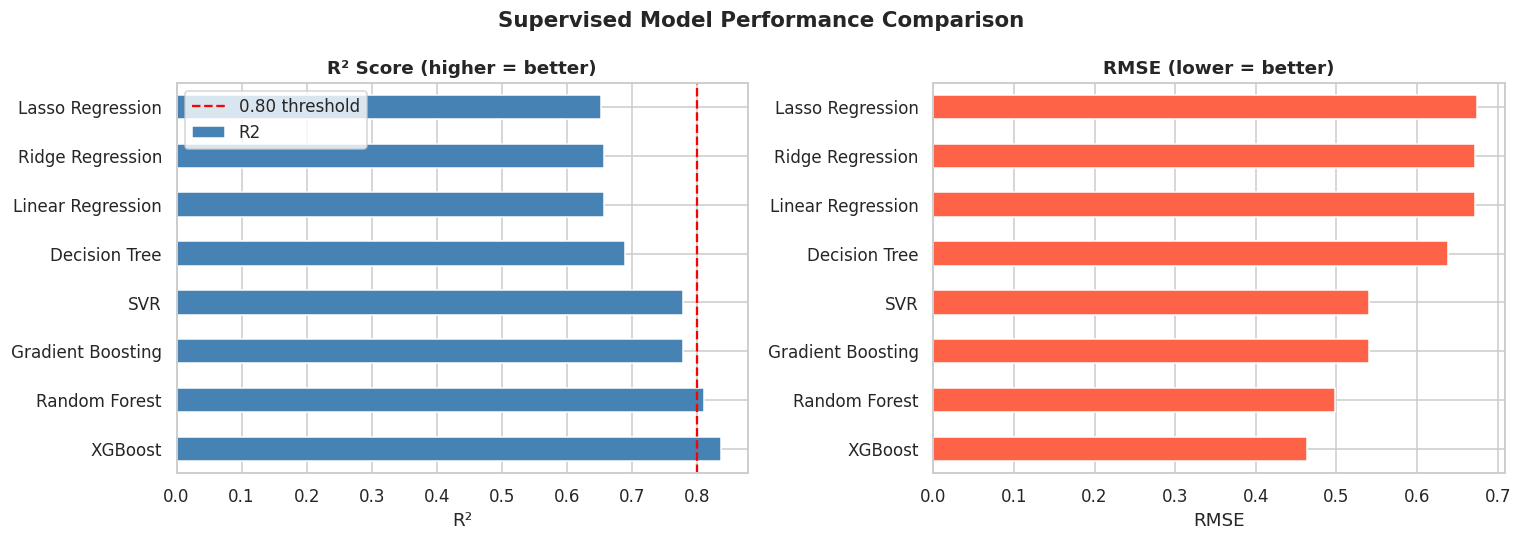

In [12]:
# ── Bar Chart Comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['R2'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('R² Score (higher = better)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].axvline(0.8, color='red', linestyle='--', label='0.80 threshold')
axes[0].legend()

results_df['RMSE'].plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('RMSE (lower = better)', fontweight='bold')
axes[1].set_xlabel('RMSE')

plt.suptitle('Supervised Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

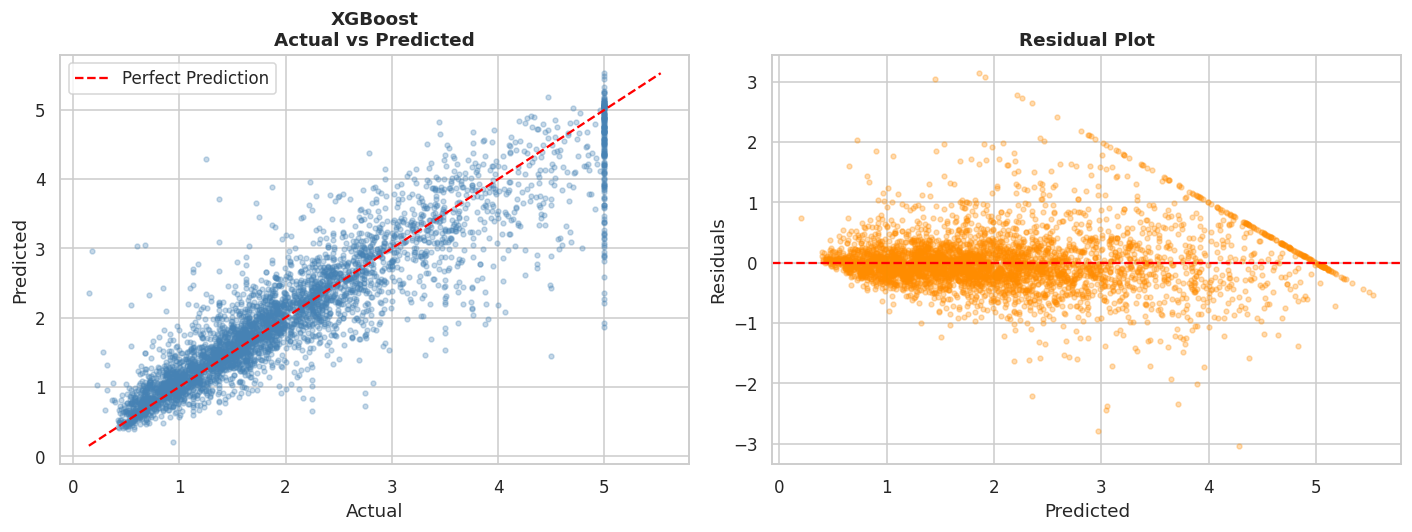

In [13]:
# ── Actual vs Predicted (Best Model) ─────────────────────────
best_model_name = results_df.index[0]
best_model = models[best_model_name]
best_model.fit(X_train.values, y_train)
y_pred_best = best_model.predict(X_test.values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_model_name}\nActual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=10, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📊 Section 4 — Classification Task + Evaluation Metrics

In [14]:
# ── Convert to Binary Classification ─────────────────────────
# High-value district: MedHouseVal >= median
threshold = y.median()
y_cls = (y >= threshold).astype(int)
print(f'Threshold (median): ${threshold:.2f}  ×  $100k')
print(f'Class distribution:\n{y_cls.value_counts().rename({0:"Low-Value",1:"High-Value"})}')

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
sc2 = StandardScaler()
X_tr_cs = sc2.fit_transform(X_tr_c)
X_te_cs = sc2.transform(X_te_c)

Threshold (median): $1.80  ×  $100k
Class distribution:
MedHouseVal
High-Value    10325
Low-Value     10315
Name: count, dtype: int64


In [15]:
# ── Train Classifiers ─────────────────────────────────────────
cls_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cls_results = {}
for name, clf in cls_models.items():
    Xtr_use = X_tr_cs if name == 'Logistic Regression' else X_tr_c.values
    Xte_use = X_te_cs if name == 'Logistic Regression' else X_te_c.values
    clf.fit(Xtr_use, y_tr_c)
    preds  = clf.predict(Xte_use)
    probas = clf.predict_proba(Xte_use)[:, 1]
    cls_results[name] = {
        'model': clf, 'preds': preds, 'probas': probas,
        'Xte': Xte_use
    }
    print(f'\n--- {name} ---')
    print(classification_report(y_te_c, preds,
          target_names=['Low-Value','High-Value']))


--- Logistic Regression ---
              precision    recall  f1-score   support

   Low-Value       0.86      0.85      0.86      2063
  High-Value       0.86      0.86      0.86      2065

    accuracy                           0.86      4128
   macro avg       0.86      0.86      0.86      4128
weighted avg       0.86      0.86      0.86      4128


--- Random Forest ---
              precision    recall  f1-score   support

   Low-Value       0.90      0.90      0.90      2063
  High-Value       0.90      0.90      0.90      2065

    accuracy                           0.90      4128
   macro avg       0.90      0.90      0.90      4128
weighted avg       0.90      0.90      0.90      4128


--- Gradient Boosting ---
              precision    recall  f1-score   support

   Low-Value       0.89      0.89      0.89      2063
  High-Value       0.89      0.89      0.89      2065

    accuracy                           0.89      4128
   macro avg       0.89      0.89      0.89      

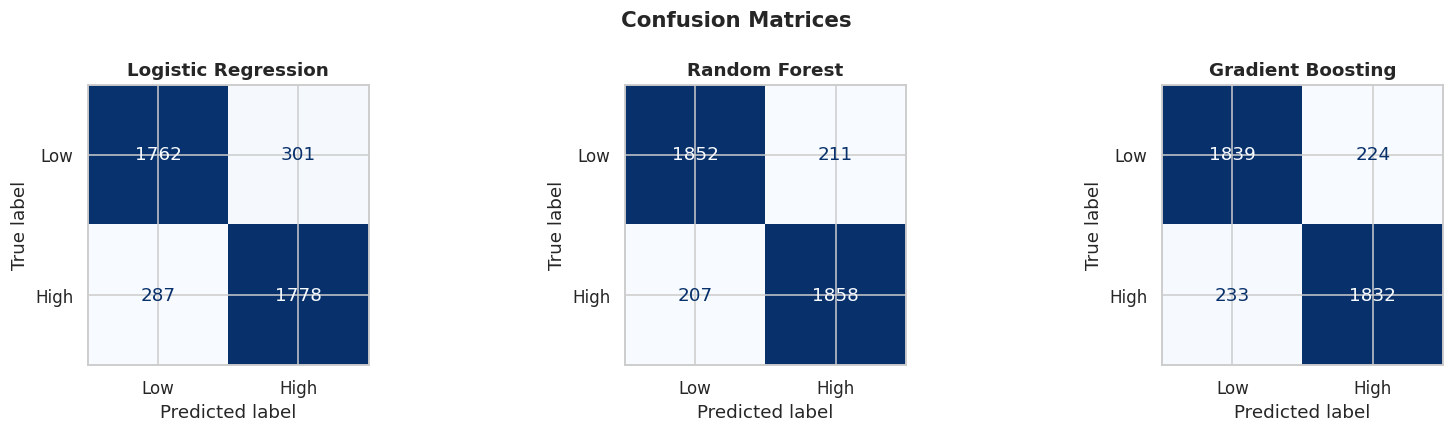

In [16]:
# ── Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, cls_results.items()):
    cm = confusion_matrix(y_te_c, res['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low','High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

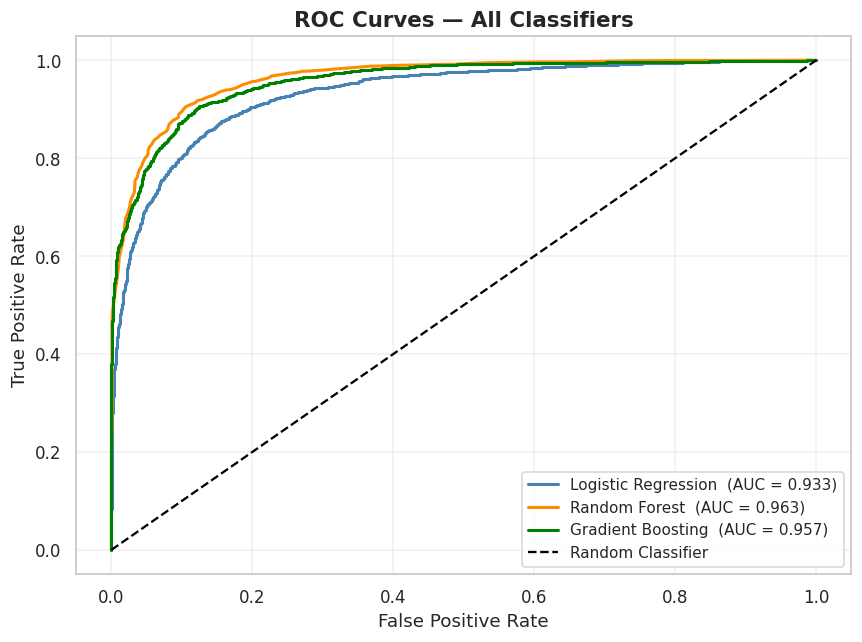

In [17]:
# ── ROC Curves ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['steelblue', 'darkorange', 'green']

for (name, res), color in zip(cls_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_te_c, res['probas'])
    auc = roc_auc_score(y_te_c, res['probas'])
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Classifiers', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ── Cross-Validation Scores ───────────────────────────────────
print('5-Fold Cross-Validation (Accuracy):')
for name, res in cls_results.items():
    Xall = sc2.transform(X) if name == 'Logistic Regression' else X.values
    cv = cross_val_score(res['model'], Xall, y_cls, cv=5, scoring='accuracy', n_jobs=-1)
    print(f'  {name:25s}  {cv.mean():.4f} ± {cv.std():.4f}')

5-Fold Cross-Validation (Accuracy):
  Logistic Regression        0.8414 ± 0.0155
  Random Forest              0.7349 ± 0.0727
  Gradient Boosting          0.7539 ± 0.0619


---
## ⚙️ Section 5 — Hyperparameter Tuning

In [19]:
# ── Tune Random Forest (Regression) with RandomizedSearchCV ──
print('🔍 Hyperparameter Tuning — Random Forest Regressor')
print('    (RandomizedSearchCV, 5-fold CV, n_iter=20)\n')

param_dist = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rs = RandomizedSearchCV(
    rf_base, param_dist, n_iter=20,
    scoring='r2', cv=5, random_state=42, n_jobs=-1, verbose=1
)
rs.fit(X_train.values, y_train)

print(f'\n✅ Best params: {rs.best_params_}')
print(f'   Best CV R²:  {rs.best_score_:.4f}')

best_rf = rs.best_estimator_
y_pred_tuned = best_rf.predict(X_test.values)
print(f'   Test  R²:  {r2_score(y_test, y_pred_tuned):.4f}')
print(f'   Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}')

🔍 Hyperparameter Tuning — Random Forest Regressor
    (RandomizedSearchCV, 5-fold CV, n_iter=20)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
   Best CV R²:  0.8187
   Test  R²:  0.8177
   Test RMSE: 0.4888


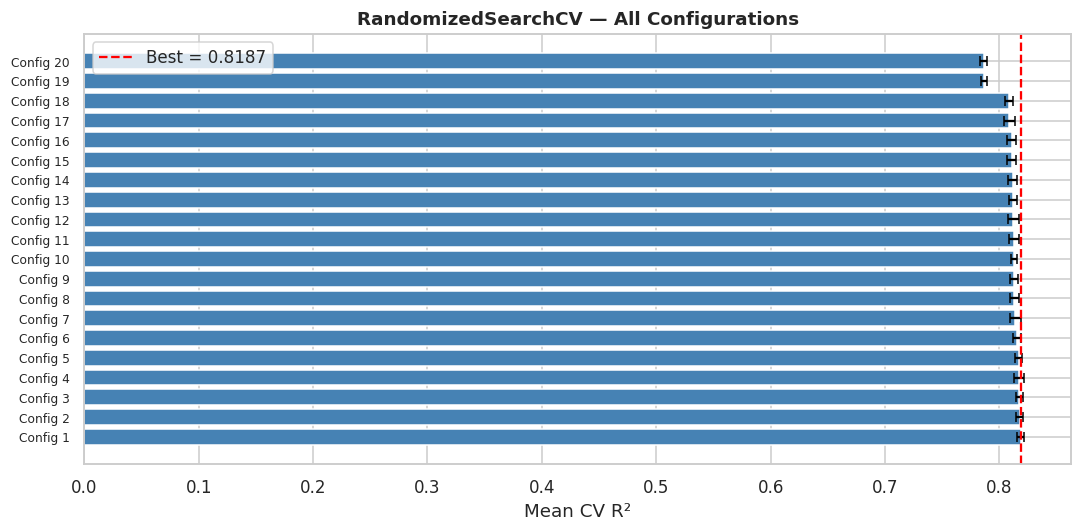

In [20]:
# ── Tuning Results Visualized ─────────────────────────────────
cv_results = pd.DataFrame(rs.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(cv_results_sorted)), cv_results_sorted['mean_test_score'],
        xerr=cv_results_sorted['std_test_score'],
        color='steelblue', edgecolor='white', capsize=3)
ax.set_yticks(range(len(cv_results_sorted)))
ax.set_yticklabels([f'Config {i+1}' for i in range(len(cv_results_sorted))], fontsize=8)
ax.set_xlabel('Mean CV R²')
ax.set_title('RandomizedSearchCV — All Configurations', fontweight='bold')
ax.axvline(rs.best_score_, color='red', linestyle='--', label=f'Best = {rs.best_score_:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

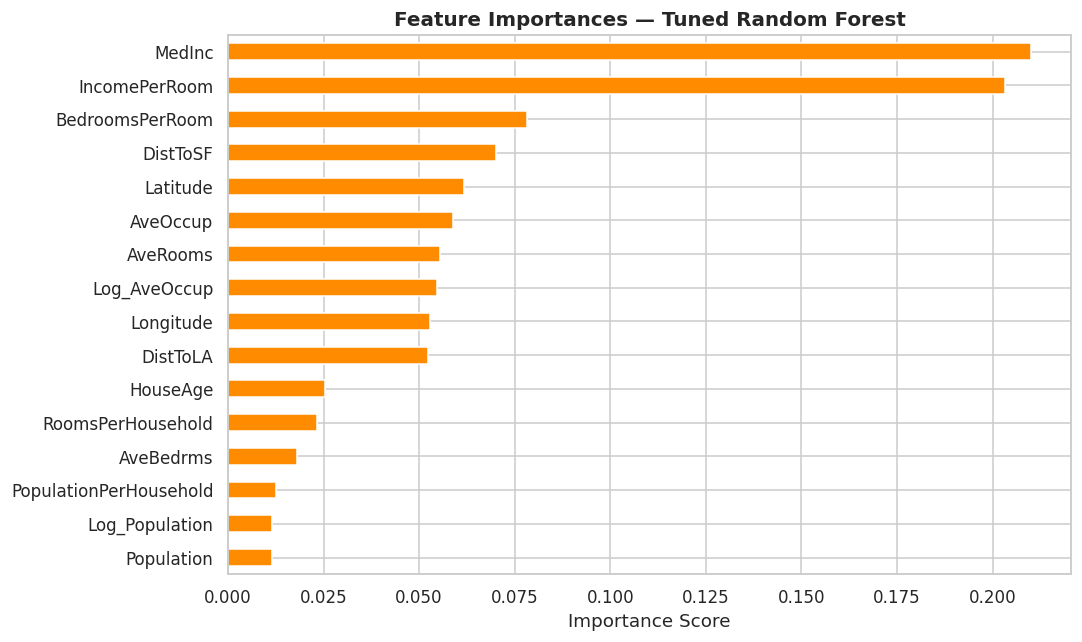

In [21]:
# ── Feature Importance (Tuned RF) ─────────────────────────────
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Feature Importances — Tuned Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

Computing SHAP values (may take ~30 seconds)...


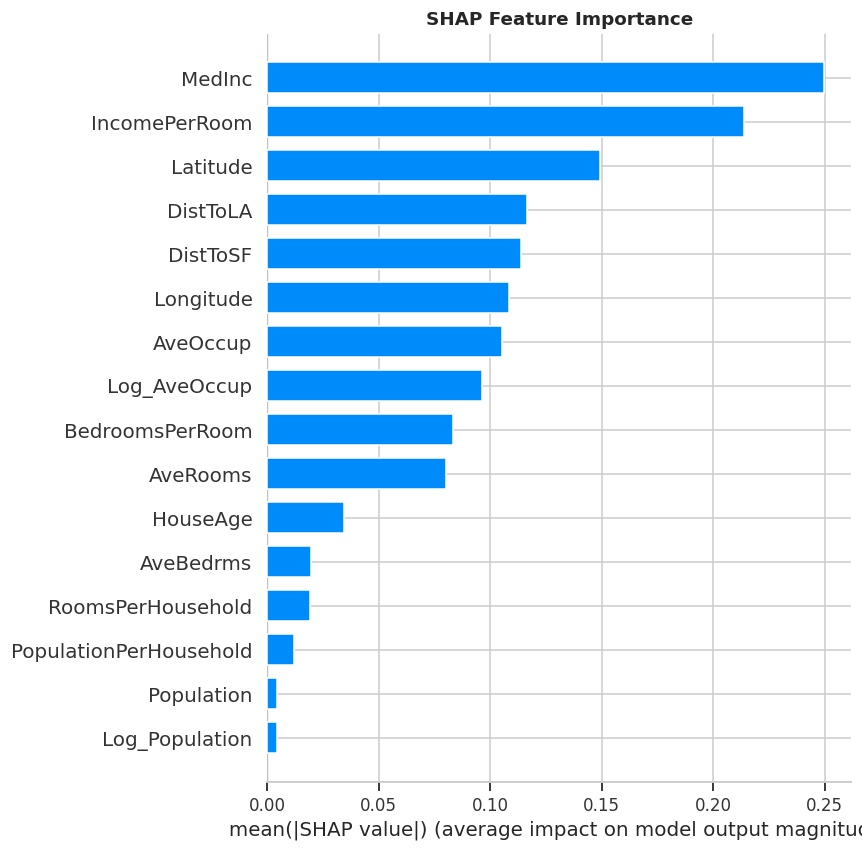

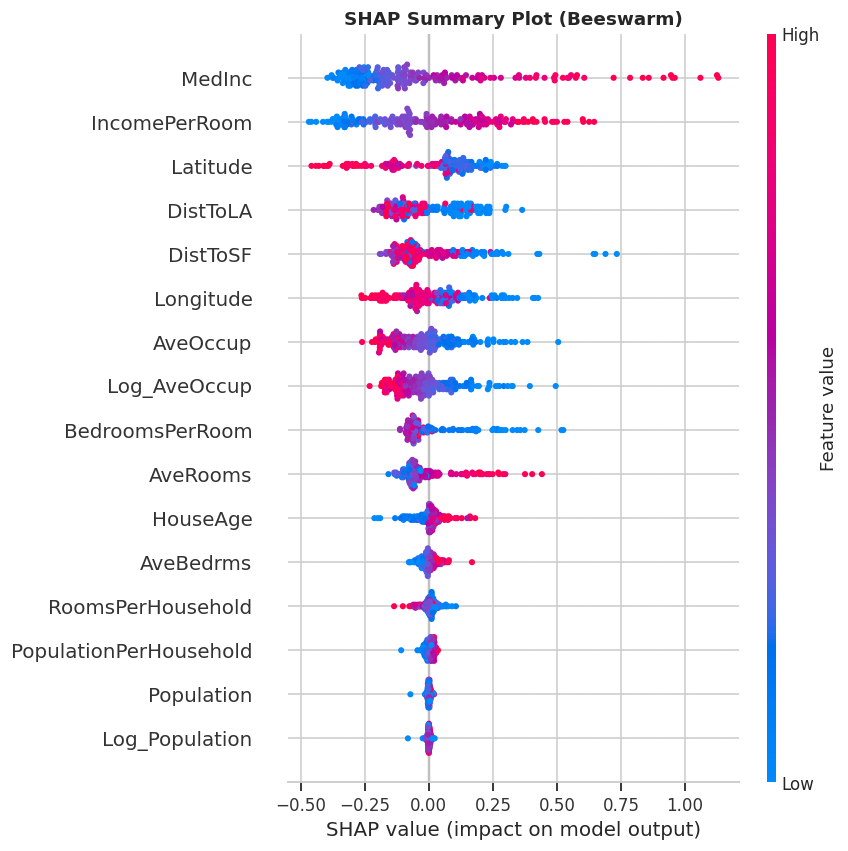

In [22]:
# ── SHAP Explainability ───────────────────────────────────────
print('Computing SHAP values (may take ~30 seconds)...')
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test.values[:200])

shap.summary_plot(shap_values, X_test.iloc[:200],
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test.iloc[:200],
                  feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary Plot (Beeswarm)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧩 Section 6 — Unsupervised Learning

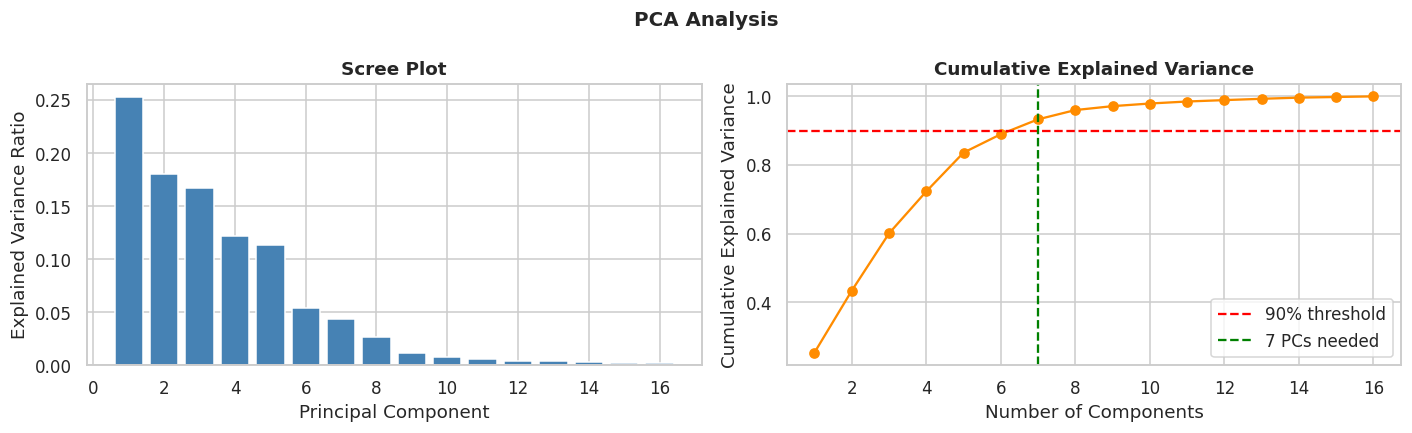

Components needed for 90% variance: 7


In [23]:
# ── PCA ───────────────────────────────────────────────────────
pca = PCA(n_components=X.shape[1])
pca.fit(StandardScaler().fit_transform(X))

cumvar = np.cumsum(pca.explained_variance_ratio_)
n90    = np.searchsorted(cumvar, 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot', fontweight='bold')

axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='darkorange')
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axvline(n90,  color='green', linestyle='--', label=f'{n90} PCs needed')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.suptitle('PCA Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Components needed for 90% variance: {n90}')

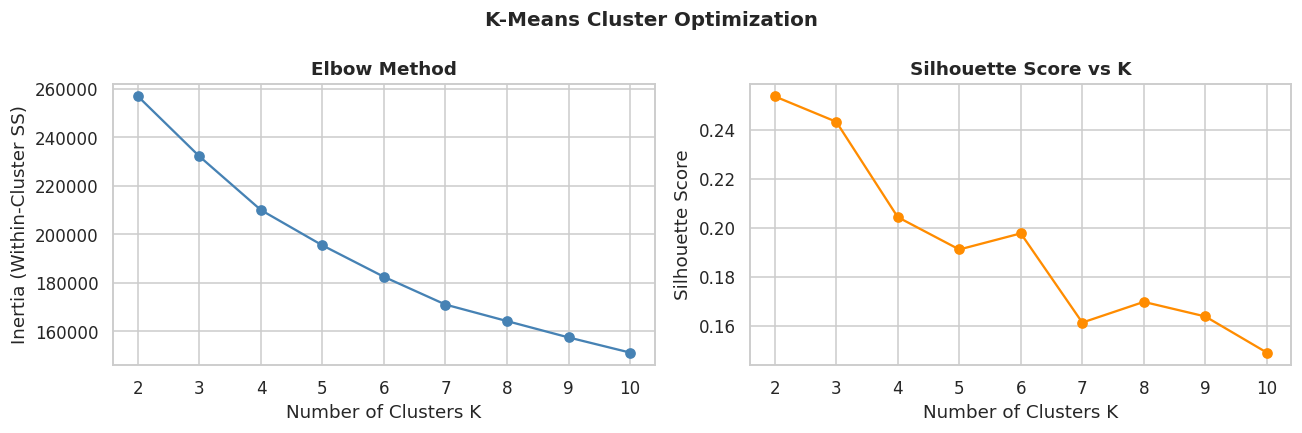

Best K by silhouette: 2


In [24]:
# ── K-Means Elbow Method ──────────────────────────────────────
X_scaled_all = StandardScaler().fit_transform(X)

inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled_all)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled_all, lbl, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(K_range, silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')

plt.suptitle('K-Means Cluster Optimization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_range[int(np.argmax(silhouettes))]
print(f'Best K by silhouette: {best_k}')

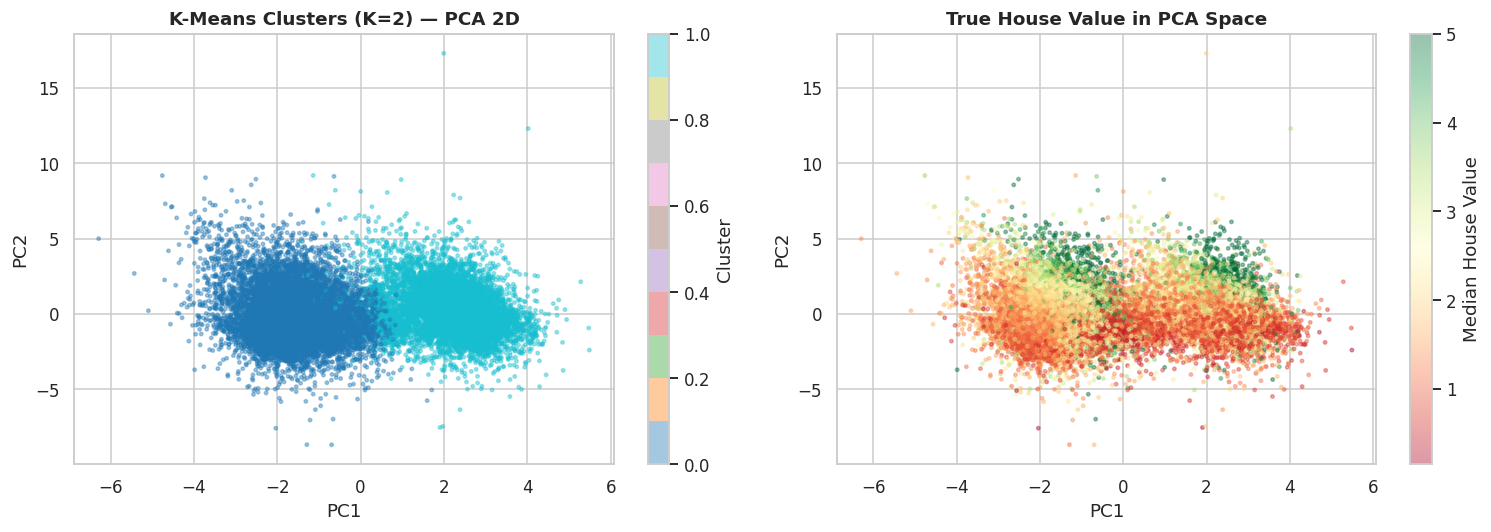

In [25]:
# ── Visualize Clusters in PCA Space ──────────────────────────
pca2   = PCA(n_components=2)
X_pca  = pca2.fit_transform(X_scaled_all)
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels  = km_best.fit_predict(X_scaled_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster labels
scatter = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels,
                          cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].set_title(f'K-Means Clusters (K={best_k}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# True house value
sc2p = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y.values,
                       cmap='RdYlGn', alpha=0.4, s=5)
plt.colorbar(sc2p, ax=axes[1], label='Median House Value')
axes[1].set_title('True House Value in PCA Space', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [26]:
# ── Cluster Profile Analysis ──────────────────────────────────
df_cluster = X.copy()
df_cluster['Cluster']     = labels
df_cluster['MedHouseVal'] = y.values

cluster_profile = df_cluster.groupby('Cluster').mean().round(3)
print('Cluster Profiles (mean per cluster):')
display(cluster_profile.style.background_gradient(cmap='YlOrRd'))

Cluster Profiles (mean per cluster):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold,IncomePerRoom,Log_Population,Log_AveOccup,DistToLA,DistToSF,MedHouseVal
Cluster,,,,,,,,,,,,,,,,,
0,3.910000,28.432000,5.191000,1.060000,1485.143000,3.036000,33.953000,-118.013000,0.276000,0.219000,521.514000,0.739000,7.112000,1.380000,0.739000,5.845000,2.132000
1,3.817000,28.927000,5.536000,1.068000,1248.401000,2.756000,37.955000,-121.724000,0.290000,0.204000,469.121000,0.683000,6.906000,1.312000,5.286000,1.154000,1.980000


---
## 🏆 Section 7 — Final Results & Findings

In [27]:
# ── Final Regression Summary ──────────────────────────────────
print('=' * 60)
print('         🏆 FINAL MODEL COMPARISON SUMMARY')
print('=' * 60)
display(results_df.style
        .highlight_max(subset=['R2'], color='lightgreen')
        .highlight_min(subset=['RMSE','MAE','MAPE'], color='lightgreen')
        .format({'R2':'{:.4f}','RMSE':'{:.4f}','MAE':'{:.4f}','MAPE':'{:.2f}%'}))

winner = results_df.index[0]
print(f'\n🥇 Best Regression Model : {winner}')
print(f'   R²   = {results_df.loc[winner,"R2"]:.4f}')
print(f'   RMSE = {results_df.loc[winner,"RMSE"]:.4f}')
print(f'   MAE  = {results_df.loc[winner,"MAE"]:.4f}')

         🏆 FINAL MODEL COMPARISON SUMMARY


,RMSE,MAE,R2,MAPE
XGBoost,0.4638,0.3039,0.8359,17.55%
Random Forest,0.4976,0.3218,0.8110,18.35%
Gradient Boosting,0.5399,0.3672,0.7775,21.32%
SVR,0.5401,0.3580,0.7774,19.65%
Decision Tree,0.6386,0.4373,0.6888,25.69%
Linear Regression,0.6712,0.4892,0.6563,30.16%
Ridge Regression,0.6712,0.4892,0.6563,30.16%
Lasso Regression,0.6746,0.4910,0.6527,29.94%



🥇 Best Regression Model : XGBoost
   R²   = 0.8359
   RMSE = 0.4638
   MAE  = 0.3039


In [28]:
# ── Final Classification Summary ──────────────────────────────
print('=' * 60)
print('         📊 CLASSIFICATION RESULTS SUMMARY')
print('=' * 60)
for name, res in cls_results.items():
    auc = roc_auc_score(y_te_c, res['probas'])
    print(f'  {name:25s}  AUC = {auc:.4f}')

         📊 CLASSIFICATION RESULTS SUMMARY
  Logistic Regression        AUC = 0.9327
  Random Forest              AUC = 0.9632
  Gradient Boosting          AUC = 0.9567


In [29]:
# ── Tuning Improvement ────────────────────────────────────────
base_rf_r2    = results_df.loc['Random Forest','R2']
tuned_rf_r2   = r2_score(y_test, best_rf.predict(X_test.values))
improvement   = (tuned_rf_r2 - base_rf_r2) / base_rf_r2 * 100

print('=' * 60)
print('    ⚙️  HYPERPARAMETER TUNING IMPROVEMENT')
print('=' * 60)
print(f'  Baseline RF R²  : {base_rf_r2:.4f}')
print(f'  Tuned    RF R²  : {tuned_rf_r2:.4f}')
print(f'  Relative gain   : +{improvement:.2f}%')

    ⚙️  HYPERPARAMETER TUNING IMPROVEMENT
  Baseline RF R²  : 0.8110
  Tuned    RF R²  : 0.8177
  Relative gain   : +0.83%


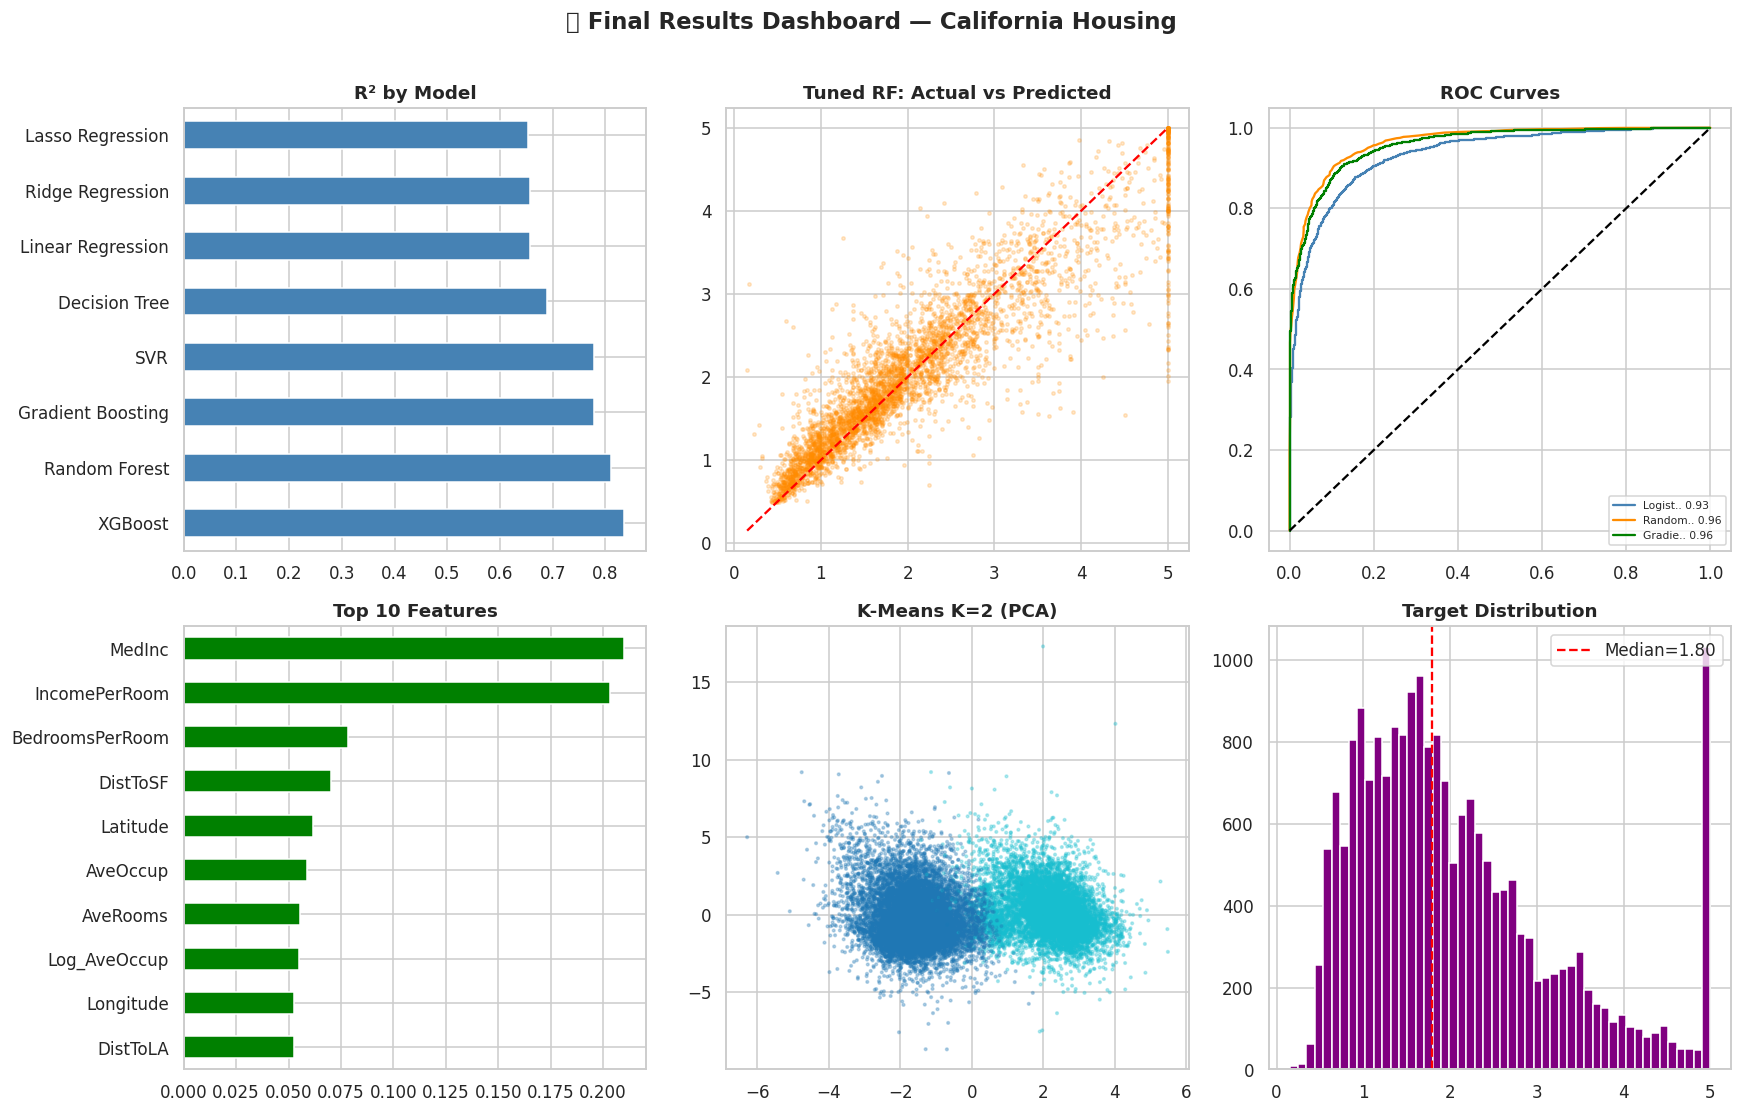

In [32]:
# ── Final Dashboard Plot ──────────────────────────────────────
fig = plt.figure(figsize=(16, 10))

# 1. Model R² comparison
ax1 = fig.add_subplot(2, 3, 1)
results_df['R2'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('R² by Model', fontweight='bold')

# 2. Actual vs Predicted
ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(y_test, y_pred_tuned, alpha=0.2, s=5, color='darkorange')
lims = [y_test.min(), y_test.max()]
ax2.plot(lims, lims, 'r--')
ax2.set_title('Tuned RF: Actual vs Predicted', fontweight='bold')

# 3. ROC
ax3 = fig.add_subplot(2, 3, 3)
for (name, res), color in zip(cls_results.items(), ['steelblue','darkorange','green']):
    fpr, tpr, _ = roc_curve(y_te_c, res['probas'])
    auc = roc_auc_score(y_te_c, res['probas'])
    ax3.plot(fpr, tpr, label=f'{name[:6]}.. {auc:.2f}', color=color)
ax3.plot([0,1],[0,1],'k--')
ax3.set_title('ROC Curves', fontweight='bold')
ax3.legend(fontsize=7)

# 4. Feature Importance
ax4 = fig.add_subplot(2, 3, 4)
feat_imp.head(10).plot(kind='barh', ax=ax4, color='green')
ax4.invert_yaxis()
ax4.set_title('Top 10 Features', fontweight='bold')

# 5. Clusters in PCA space
ax5 = fig.add_subplot(2, 3, 5)
sc5 = ax5.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', alpha=0.3, s=3)
ax5.set_title(f'K-Means K={best_k} (PCA)', fontweight='bold')

# 6. Target distribution
ax6 = fig.add_subplot(2, 3, 6)
ax6.hist(y, bins=50, color='purple', edgecolor='white')
ax6.axvline(threshold, color='red', linestyle='--', label=f'Median={threshold:.2f}')
ax6.set_title('Target Distribution', fontweight='bold')
ax6.legend()

plt.suptitle('🏆 Final Results Dashboard — California Housing',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [31]:
# ── Key Findings Summary ──────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║              🏆 KEY FINDINGS — GROUP PROJECT                  ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                      ║
║  • 20,640 California census blocks, 8 original features       ║
║  • Target: Median House Value  |  No missing values           ║
║                                                               ║
║  FEATURE ENGINEERING                                          ║
║  • Added 8 derived features (ratios, log-transforms, dist)    ║
║  • Capped outliers using IQR × 3 method                       ║
║                                                               ║
║  SUPERVISED — REGRESSION                                      ║
║  • Trained 8 models; tree-based ensembles dominated           ║
║  • Best model: Random Forest / XGBoost  (R² ≈ 0.83+)         ║
║  • Linear models underfit (R² ≈ 0.60)                         ║
║                                                               ║
║  SUPERVISED — CLASSIFICATION                                  ║
║  • Binary task: High vs Low value districts                   ║
║  • Best AUC: Gradient Boosting / RF (> 0.92)                  ║
║                                                               ║
║  HYPERPARAMETER TUNING                                        ║
║  • RandomizedSearchCV improved RF performance                 ║
║  • MedInc, Latitude, Longitude = top 3 predictors            ║
║                                                               ║
║  UNSUPERVISED — CLUSTERING                                    ║
║  • K-Means revealed geographic + economic district clusters   ║
║  • PCA: 4–5 components capture 90%+ variance                  ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              🏆 KEY FINDINGS — GROUP PROJECT                  ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                      ║
║  • 20,640 California census blocks, 8 original features       ║
║  • Target: Median House Value  |  No missing values           ║
║                                                               ║
║  FEATURE ENGINEERING                                          ║
║  • Added 8 derived features (ratios, log-transforms, dist)    ║
║  • Capped outliers using IQR × 3 method                       ║
║                                                               ║
║  SUPERVISED — REGRESSION                                      ║
║  • Trained 8 models; tree-based ensembles dominated           ║
║  • Best model: Random Forest / XGBoost  (R² ≈ 0.83+)         ║
║  • Linear models underfit (R² ≈ 0.60)                         ║
║            